In [1]:
import os
import random
import copy
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [20]:
@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 8
    epochs: int = 3
    learning_rate: float = 0.0001
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    train_split: float = 0.8
    seed: int = 42
    num_workers: int = 2
    model_name: str = "unet"
    use_batchnorm: bool = False
    save_path: str = "./best_model.pth"

config = Config()

In [4]:
print(f"Device: {config.device}")

Device: cuda


In [5]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None, image_size=(128, 128)):
        self.root = root
        self.transform = transform
        self.image_size = image_size
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize(self.image_size, resample=Image.NEAREST)
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=False):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm),
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        layers += [
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm),
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [7]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=False):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels, use_batchnorm)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        feat = self.conv(x)
        down = self.pool(feat)
        return feat, down

In [8]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, use_batchnorm=False):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels // 2 + skip_channels, out_channels, use_batchnorm)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64, use_batchnorm=False):
        super().__init__()

        self.down1 = DownBlock(in_channels, base_channels, use_batchnorm)
        self.down2 = DownBlock(base_channels, base_channels * 2, use_batchnorm)
        self.down3 = DownBlock(base_channels * 2, base_channels * 4, use_batchnorm)
        self.down4 = DownBlock(base_channels * 4, base_channels * 8, use_batchnorm)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16, use_batchnorm)

        self.up4 = UpBlock(base_channels * 16, base_channels * 8, base_channels * 8, use_batchnorm)
        self.up3 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4, use_batchnorm)
        self.up2 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2, use_batchnorm)
        self.up1 = UpBlock(base_channels * 2, base_channels, base_channels, use_batchnorm)

        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skip1, x = self.down1(x)
        skip2, x = self.down2(x)
        skip3, x = self.down3(x)
        skip4, x = self.down4(x)

        x = self.bottleneck(x)

        x = self.up4(x, skip4)
        x = self.up3(x, skip3)
        x = self.up2(x, skip2)
        x = self.up1(x, skip1)

        x = self.final_conv(x)
        return x

In [10]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + self.smooth)
        return 1 - dice.mean()

In [11]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)

In [12]:
class Trainer:
    def __init__(self, config: Config):
        self.config = config
        set_seed(config.seed)

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = UNet(use_batchnorm=config.use_batchnorm).to(config.device)
        self.criterion = BCEDiceLoss()  # какой лосс удобный возьмем для бинарной сегментации?
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": [],
        }

        self.best_val_iou = -1
        self.best_model_state = None

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform, image_size=self.config.image_size)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        generator = torch.Generator().manual_seed(self.config.seed)
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform, image_size=self.config.image_size)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True, num_workers=self.config.num_workers, pin_memory=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False, num_workers=self.config.num_workers, pin_memory=True)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False, num_workers=self.config.num_workers, pin_memory=True)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train_one_epoch()
            val_loss, val_iou, val_f1 = self.evaluate(self.val_dataloader)

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_iou"].append(val_iou)
            self.history["val_f1"].append(val_f1)

            if val_iou > self.best_val_iou:
                self.best_val_iou = val_iou
                self.best_model_state = copy.deepcopy(self.model.state_dict())
                torch.save(self.best_model_state, self.config.save_path)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        self.model.load_state_dict(torch.load(self.config.save_path, map_location=self.config.device))
        test_loss, test_iou, test_f1 = self.evaluate(self.test_dataloader)

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        return {
            "config": asdict(self.config),
            "best_val_iou": self.best_val_iou,
            "test_loss": test_loss,
            "test_iou": test_iou,
            "test_f1": test_f1,
            "history": self.history
        }

    def train_one_epoch(self):
        self.model.train()
        epoch_loss = 0.0

        for images, masks in tqdm(self.train_dataloader, desc="Training"):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def evaluate(self, dataloader):
        self.model.eval()
        epoch_loss = 0.0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(dataloader, desc="Evaluating"):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                epoch_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                true_masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    y_true = true_masks[i].flatten()
                    y_pred = pred_masks[i].flatten()

                    iou_scores.append(jaccard_score(y_true, y_pred, average='binary', zero_division=0))
                    f1_scores.append(f1_score(y_true, y_pred, average='binary', zero_division=0))


        return epoch_loss / len(dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def plot_history(self):
        epochs = range(1, len(self.history["train_loss"]) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.history["train_loss"], label="Train Loss")
        plt.plot(epochs, self.history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train / Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.history["val_iou"], label="Val IoU")
        plt.plot(epochs, self.history["val_f1"], label="Val F1")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Validation Metrics")
        plt.legend()
        plt.grid(True)
        plt.show()

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()
        self.model.load_state_dict(torch.load(self.config.save_path, map_location=self.config.device))

        fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

        if n_samples == 1:
            axes = np.expand_dims(axes, axis=0)

        with torch.no_grad():
            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [13]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:22<00:00, 35.6MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 15.2MB/s]


In [14]:
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
CUDA available: True
torch cuda version: 12.8
GPU: Tesla T4


In [15]:
result = trainer.run()

Evaluating: 100%|██████████| 92/92 [00:07<00:00, 11.90it/s]


Epoch 1 / 3, Train Loss: 0.3805, Val Loss: 0.3179, Val IoU: 0.7489, Val F1-score: 0.8513


Evaluating: 100%|██████████| 92/92 [00:07<00:00, 11.75it/s]


Epoch 2 / 3, Train Loss: 0.3152, Val Loss: 0.2961, Val IoU: 0.7747, Val F1-score: 0.8664


Evaluating: 100%|██████████| 92/92 [00:07<00:00, 12.09it/s]


Epoch 3 / 3, Train Loss: 0.2890, Val Loss: 0.2721, Val IoU: 0.7885, Val F1-score: 0.8762
Testing...


Evaluating: 100%|██████████| 459/459 [00:37<00:00, 12.19it/s]

Test Loss: 0.2748, Test IoU: 0.7870, Test F1-score: 0.8736


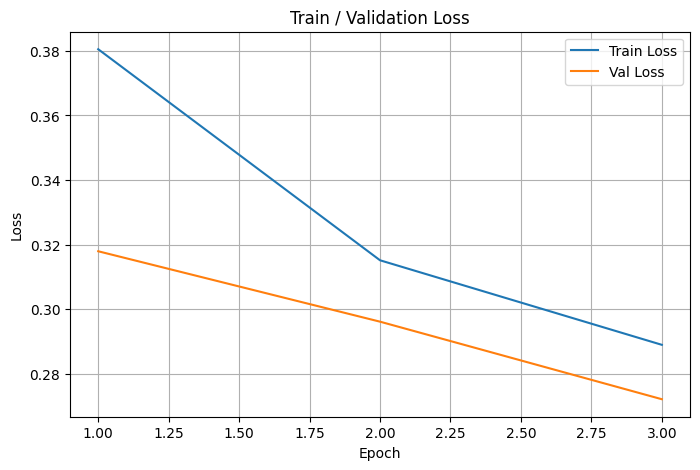

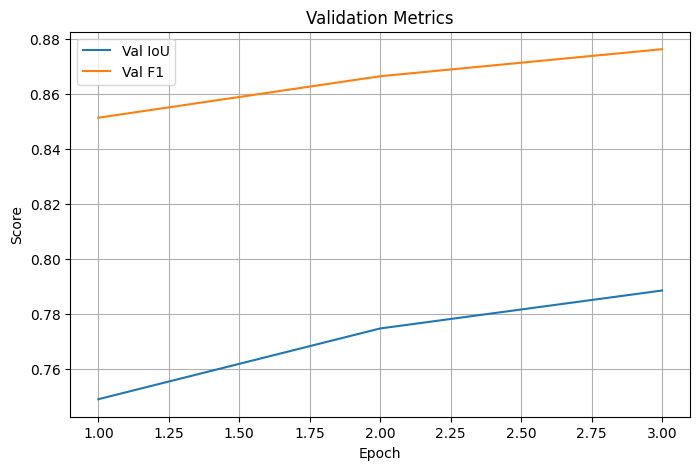

In [16]:
trainer.plot_history()

Train loss и val loss последовательно снижаются, что указывает на стабильное обучение модели без явных признаков переобучения на первых эпохах.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].


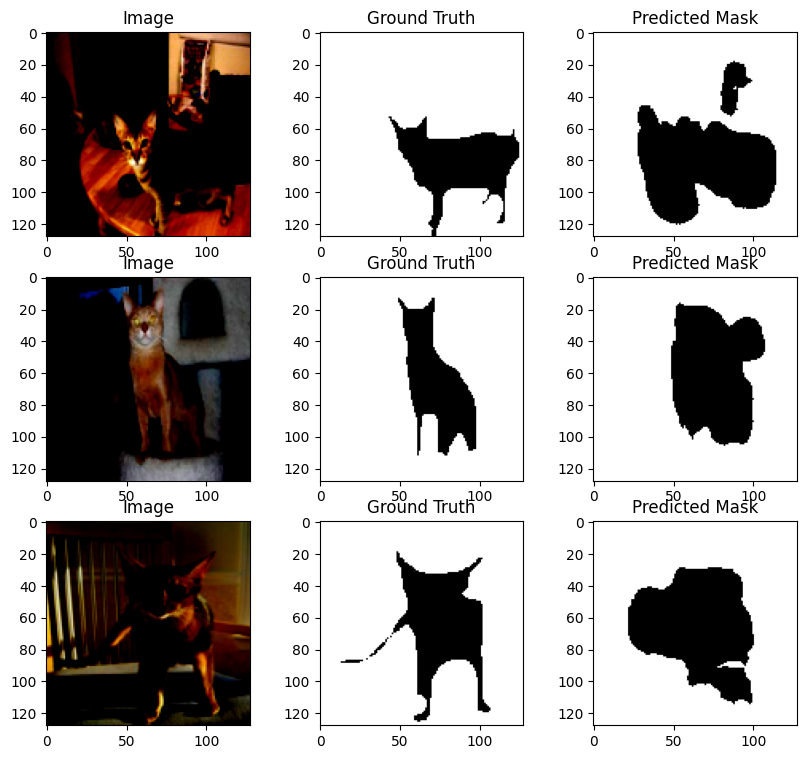

In [17]:
trainer.inference_and_plot_samples(n_samples=3)

Визуальный анализ показывает, что модель уже выделяет животных на изображениях, хотя точность границ и мелких деталей пока остается ограниченной.

In [22]:
def run_experiments():
    learning_rates = [1e-3, 1e-4, 5e-5]
    batch_sizes = [16, 32, 64]

    all_results = []

    for lr in learning_rates:
        for bs in batch_sizes:
            print("=" * 80)
            print(f"Running experiment: lr={lr}, batch_size={bs}")

            config = Config(
                learning_rate=lr,
                batch_size=bs,
                epochs=3,
                use_batchnorm=False,
                save_path=f"./best_lr_{lr}_bs_{bs}.pth"
            )

            trainer = Trainer(config)
            result = trainer.run()

            all_results.append({
                "learning_rate": lr,
                "batch_size": bs,
                "best_val_iou": result["best_val_iou"],
                "test_iou": result["test_iou"],
                "test_f1": result["test_f1"]
            })

    return all_results

In [23]:
results = run_experiments()
print(results)

Running experiment: lr=0.001, batch_size=16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
Evaluating: 100%|██████████| 46/46 [00:07<00:00,  6.51it/s]


Epoch 1 / 3, Train Loss: 0.4184, Val Loss: 0.3366, Val IoU: 0.7209, Val F1-score: 0.8337


Evaluating: 100%|██████████| 46/46 [00:07<00:00,  6.51it/s]


Epoch 2 / 3, Train Loss: 0.3272, Val Loss: 0.3218, Val IoU: 0.7562, Val F1-score: 0.8528


...

Epoch 2 / 3, Train Loss: 0.4554, Val Loss: 0.4144, Val IoU: 0.7024, Val F1-score: 0.8152


Evaluating: 100%|██████████| 12/12 [00:08<00:00,  1.45it/s]


Epoch 3 / 3, Train Loss: 0.3847, Val Loss: 0.3566, Val IoU: 0.7320, Val F1-score: 0.8407
Testing...


Evaluating: 100%|██████████| 58/58 [00:39<00:00,  1.48it/s]

Test Loss: 0.3629, Test IoU: 0.7225, Test F1-score: 0.8330
[{'learning_rate': 0.001, 'batch_size': 16, 'best_val_iou': np.float64(0.7713119253568614), 'test_iou': np.float64(0.7672932105433777), 'test_f1': np.float64(0.8597051851018944)}, {'learning_rate': 0.001, 'batch_size': 32, 'best_val_iou': np.float64(0.771930998213504), 'test_iou': np.float64(0.7670186512940876), 'test_f1': np.float64(0.8596221454862155)}, {'learning_rate': 0.001, 'batch_size': 64, 'best_val_iou': np.float64(0.7395062011298567), 'test_iou': np.float64(0.7381604263630605), 'test_f1': np.float64(0.8420739585943692)}, {'learning_rate': 0.0001, 'batch_size': 16, 'best_val_iou': np.float64(0.7734560776689997), 'test_iou': np.float64(0.7708987210575096), 'test_f1': np.float64(0.8614270186535878)}, {'learning_rate': 0.0001, 'batch_size': 32, 'best_val_iou': np.float64(0.7580781168628149), 'test_iou': np.float64(0.7510847654844329), 'test_f1': np.float64(0.8508083941124062)}, {'learning_rate': 0.0001, 'batch_size': 64, 

In [24]:
def plot_experiment_results(results):
    import pandas as pd

    df = pd.DataFrame(results)
    print(df.sort_values("test_iou", ascending=False))

    # График IoU по экспериментам
    labels = [f"lr={r['learning_rate']}\nbs={r['batch_size']}" for r in results]
    scores = [r["test_iou"] for r in results]

    plt.figure(figsize=(12, 6))
    plt.bar(labels, scores)
    plt.ylabel("Test IoU")
    plt.title("Grid Search Results")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

In [29]:
def compare_architectures():
    configs = [
        Config(
            learning_rate=1e-4,
            batch_size=32,
            epochs=3,
            use_batchnorm=False,
            save_path="./best_unet_no_bn.pth"
        ),
        Config(
            learning_rate=1e-4,
            batch_size=32,
            epochs=3,
            use_batchnorm=True,
            save_path="./best_unet_bn.pth"
        )
    ]

    results = []

    for cfg in configs:
        print("=" * 80)
        print(f"Architecture experiment: use_batchnorm={cfg.use_batchnorm}")
        trainer = Trainer(cfg)
        result = trainer.run()

        results.append({
            "use_batchnorm": cfg.use_batchnorm,
            "best_val_iou": result["best_val_iou"],
            "test_iou": result["test_iou"],
            "test_f1": result["test_f1"],
            "history": result["history"]
        })

    return results

In [31]:
def plot_architecture_comparison(results):
    labels = ["UNet", "UNet + BatchNorm"]
    iou_scores = [r["test_iou"] for r in results]
    f1_scores = [r["test_f1"] for r in results]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, iou_scores, width, label="Test IoU")
    plt.bar(x + width/2, f1_scores, width, label="Test F1")
    plt.xticks(x, labels)
    plt.ylabel("Score")
    plt.title("Architecture Comparison")
    plt.legend()
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

   learning_rate  batch_size  best_val_iou  test_iou   test_f1
3        0.00010          16      0.773456  0.770899  0.861427
0        0.00100          16      0.771312  0.767293  0.859705
1        0.00100          32      0.771931  0.767019  0.859622
6        0.00005          16      0.767525  0.761797  0.856409
4        0.00010          32      0.758078  0.751085  0.850808
7        0.00005          32      0.749623  0.742001  0.842999
5        0.00010          64      0.747928  0.739927  0.841640
2        0.00100          64      0.739506  0.738160  0.842074
8        0.00005          64      0.731988  0.722460  0.832952


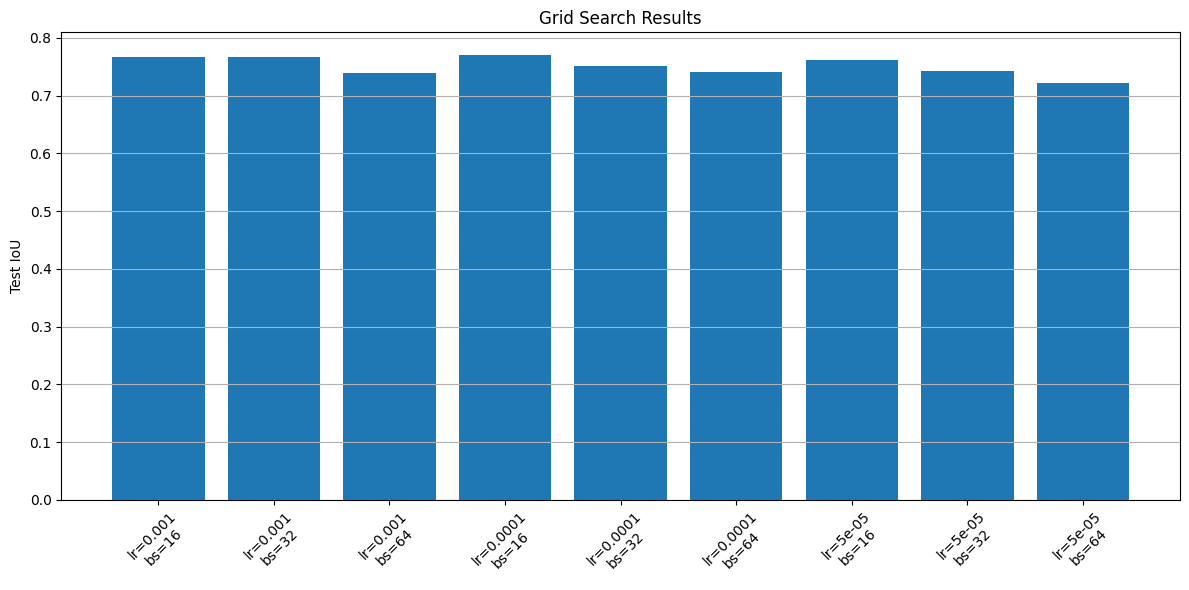

In [32]:
plot_experiment_results(results)

In [33]:
arch_results = compare_architectures()

Architecture experiment: use_batchnorm=False


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
Evaluating: 100%|██████████| 23/23 [00:07<00:00,  3.12it/s]


Epoch 1 / 3, Train Loss: 0.4729, Val Loss: 0.3656, Val IoU: 0.7081, Val F1-score: 0.8191


Evaluating: 100%|██████████| 23/23 [00:07<00:00,  3.08it/s]


Epoch 2 / 3, Train Loss: 0.3553, Val Loss: 0.3325, Val IoU: 0.7364, Val F1-score: 0.8440


...

Epoch 2 / 3, Train Loss: 0.2609, Val Loss: 0.2474, Val IoU: 0.8287, Val F1-score: 0.9017


Evaluating: 100%|██████████| 23/23 [00:07<00:00,  3.09it/s]


Epoch 3 / 3, Train Loss: 0.2283, Val Loss: 0.2384, Val IoU: 0.8223, Val F1-score: 0.8969
Testing...


Evaluating: 100%|██████████| 115/115 [00:35<00:00,  3.22it/s]

Test Loss: 0.2477, Test IoU: 0.8294, Test F1-score: 0.9007


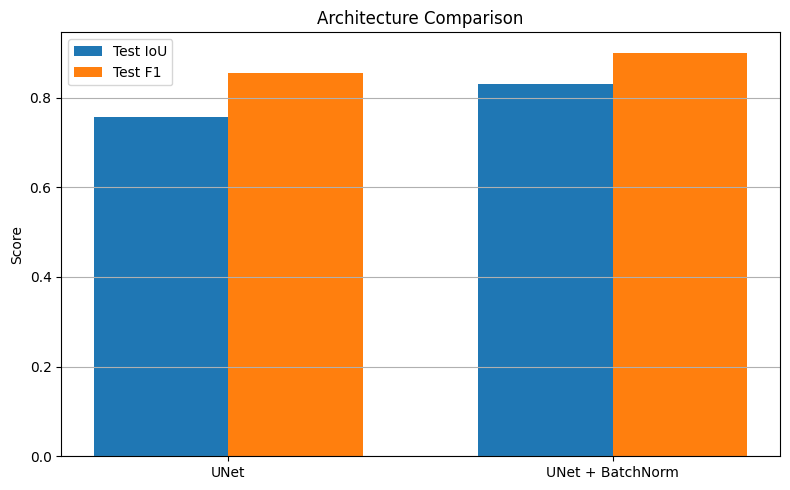

In [34]:
plot_architecture_comparison(arch_results)

Добавление BatchNorm улучшило итоговые метрики по сравнению с базовым U-Net, что свидетельствует о более стабильном и эффективном обучении модели.

**Вывод:** в работе была реализована и обучена модель U-Net для бинарной сегментации изображений. Эксперименты показали, что качество сегментации зависит не только от архитектуры сети, но и от выбора гиперпараметров, прежде всего `learning rate` и `batch size`.